<a href="https://colab.research.google.com/github/RivrSantos/Analise-Machine-Learning/blob/main/Exercicio_Modulo_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-13-1477774052.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = grafico.set_xticklabels(labels=df['hora'], rotation=90)


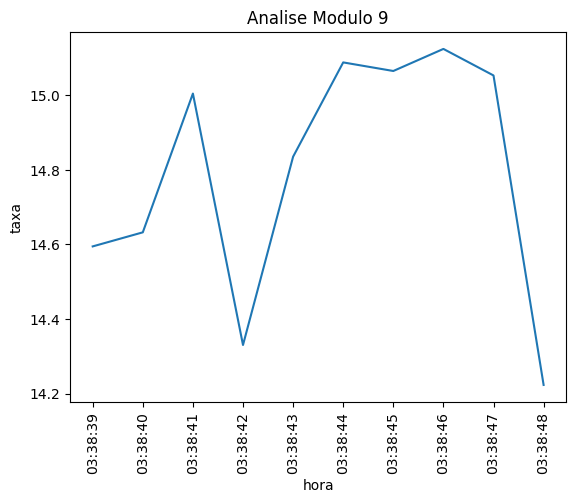

In [13]:
import os
import time
import json
import csv
from random import random
from datetime import datetime
from sys import argv
import pandas as pd
import seaborn as sns
import requests

URL = 'https://api.bcb.gov.br/dados/serie/bcdata.sgs.4392/dados'

# Captando a taxa CDI do site do BCB
try:
    response = requests.get(url=URL)
    response.raise_for_status()
except requests.HTTPError as exc:
    print("Dado não encontrado, continuando.")
    cdi = None
except Exception as exc:
    print("Erro, parando a execução.")
    raise exc
else:
    dado = json.loads(response.text)[-1]['valor']
# Criando a variável data e hora

for _ in range(0, 10):
    data_e_hora = datetime.now()
    data = datetime.strftime(data_e_hora, '%Y/%m/%d')
    hora = datetime.strftime(data_e_hora, '%H:%M:%S')

    cdi = float(dado) + (random() - 0.5)

    # Verificando se o arquivo "taxa-cdi.csv" existe
    if os.path.exists('./taxa-cdi.csv') == False:

        with open(file='./taxa-cdi.csv', mode='w', encoding='utf8') as fp:
            fp.write('data,hora,taxa\n')

    # Salvando dados no arquivo "taxa-cdi.csv"
    with open(file='taxa-cdi.csv', mode='a', encoding='utf8') as fp:
        fp.write(f'{data},{hora},{cdi}\n')
    time.sleep(1)

df = pd.read_csv('/content/taxa-cdi.csv')
grafico = sns.lineplot(x=df['hora'], y=df['taxa'])
_ = grafico.set_xticklabels(labels=df['hora'], rotation=90)
grafico.set_title('Analise Modulo 9')
grafico.get_figure().savefig(f"{argv[1]}.png")